# Analisis ML sobre `set_abcde`

Este notebook incluye:
- Regresion para predecir `PROM_CM_ACTUAL`.
- Clasificacion de alto desempeno academico.
- Clustering de perfiles estudiantiles.
- Importancia de variables (permutation importance).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    f1_score,
    classification_report,
    silhouette_score,
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [2]:
# Configuracion de ruta del dataset
# 1) Si conoces la ruta exacta, fijala en DATA_PATH.
# 2) Si no, el notebook busca automaticamente un archivo llamado set_abcde.csv.
DATA_PATH = None  # ejemplo: Path('../data/processed/2021/set_abcde.csv')

search_roots = [Path('.'), Path('..')]

def find_set_abcde():
    if DATA_PATH is not None:
        p = Path(DATA_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'No existe DATA_PATH: {p}')

    candidates = []
    for root in search_roots:
        candidates.extend(root.rglob('set_abcde.csv'))

    if not candidates:
        raise FileNotFoundError('No se encontro set_abcde.csv. Define DATA_PATH manualmente.')

    # Preferir paths mas cortos (normalmente el mas cercano al notebook)
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[0]

dataset_path = find_set_abcde()
print('Usando dataset:', dataset_path)


Usando dataset: ..\data\clean\2021\set_abcde.csv


In [3]:
df = pd.read_csv(dataset_path)
print('Shape:', df.shape)
display(df.head(3))

print('\nColumnas disponibles:')
print(df.columns.tolist())


Shape: (77366, 43)


,mrun,RBD,CODIGO_REGION_EGRESO,NOMBRE_REGION_EGRESO,PTJE_NEM,PTJE_RANKING,PROM_CM_ACTUAL,rango_edad,anio_ing_carr_ori,anio_ing_carr_act,...,TIPO_INST,ID_RBD,N EVALUADO,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto,IVM_Establecimiento,valor_corte,DISTANCIA
0,13776824,9046.0,13,Metropolitana,775,780,"791,5",15 a 19 años,2021,2021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.038050,NaN,6.927886
1,18327063,8503.0,13,Metropolitana,647,693,522,15 a 19 años,2021,2021,...,NaN,8503.0,1213.0,548.0,111.0,94.0,460.0,21.743818,20.03805,6.085296
2,23768815,12655.0,1,Tarapacá,775,850,597,15 a 19 años,2021,2021,...,NaN,12655.0,241.0,108.0,32.0,19.0,82.0,20.939412,20.03805,NaN



Columnas disponibles:
['mrun', 'RBD', 'CODIGO_REGION_EGRESO', 'NOMBRE_REGION_EGRESO', 'PTJE_NEM', 'PTJE_RANKING', 'PROM_CM_ACTUAL', 'rango_edad', 'anio_ing_carr_ori', 'anio_ing_carr_act', 'tipo_inst_1', 'tipo_inst_2', 'tipo_inst_3', 'cod_inst', 'nomb_inst', 'nomb_carrera', 'region_sede', 'provincia_sede', 'comuna_sede', 'nivel_global', 'nivel_carrera_1', 'forma_ingreso', 'NOMBRE_REGION_INGRESO', 'NOM_RBD', 'COD_REG_RB', 'TIPO_DEPEN', 'LATITUD_COL', 'LONGITUD_COL', 'NOMBRE_INS', 'REGIÓN', 'COMUNA', 'LATITUD_UNI', 'LONGITUD_UNI', 'TIPO_INST', 'ID_RBD', 'N EVALUADO', 'IVM Bajo', 'IVM Medio', 'IVM Alto', 'IVM Muy Alto', 'IVM_Establecimiento', 'valor_corte', 'DISTANCIA']


## Preparacion de variables

Se seleccionan features candidatas que suelen existir en tu pipeline `utils.py`, pero el codigo filtra dinamicamente solo las que esten presentes.

In [12]:
target_reg = 'PROM_CM_ACTUAL'
if target_reg not in df.columns:
    raise ValueError(f'No existe la columna objetivo {target_reg} en el dataset.')

candidate_features = [
    'PTJE_NEM',
    'PTJE_RANKING',
    'IVM_Establecimiento',
    'DISTANCIA',
    'TIPO_DEPEN',
    'NOMBRE_REGION_EGRESO',
    'NOMBRE_REGION_INGRESO',
    'region_sede',
    'comuna_sede',
    'tipo_inst_1',
    'tipo_inst_2',
    'nivel_global',
    'rango_edad',
]

feature_cols = [c for c in candidate_features if c in df.columns]
if not feature_cols:
    raise ValueError('No se encontraron features candidatas en el dataset.')

work = df[feature_cols + [target_reg]].copy()

# Asegurar tipos numericos esperados
for col in ['PTJE_NEM', 'PTJE_RANKING', 'IVM_Establecimiento', 'DISTANCIA', target_reg]:
    if col in work.columns:
        work[col] = pd.to_numeric(work[col], errors='coerce')

work = work.dropna(subset=[target_reg])
work  = work[work["PROM_CM_ACTUAL"] > 0]

num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(work[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print('Features usadas:', feature_cols)
print('Numericas:', num_cols)
print('Categoricas:', cat_cols)
print('Filas para modelar:', len(work))


Features usadas: ['PTJE_NEM', 'PTJE_RANKING', 'IVM_Establecimiento', 'DISTANCIA', 'TIPO_DEPEN', 'NOMBRE_REGION_EGRESO', 'NOMBRE_REGION_INGRESO', 'region_sede', 'comuna_sede', 'tipo_inst_1', 'tipo_inst_2', 'nivel_global', 'rango_edad']
Numericas: ['PTJE_NEM', 'PTJE_RANKING', 'IVM_Establecimiento', 'DISTANCIA', 'TIPO_DEPEN']
Categoricas: ['NOMBRE_REGION_EGRESO', 'NOMBRE_REGION_INGRESO', 'region_sede', 'comuna_sede', 'tipo_inst_1', 'tipo_inst_2', 'nivel_global', 'rango_edad']
Filas para modelar: 35004


## 1) Regresion: predecir `PROM_CM_ACTUAL`

In [13]:
X = work[feature_cols]
y = work[target_reg]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols),
])

baseline_reg = Pipeline([
    ('preprocess', preprocess),
    ('model', DummyRegressor(strategy='mean')),
])

rf_reg = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    )),
])

baseline_reg.fit(X_train, y_train)
rf_reg.fit(X_train, y_train)

pred_base = baseline_reg.predict(X_test)
pred_rf = rf_reg.predict(X_test)

def reg_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

res_reg = pd.DataFrame([
    {'modelo': 'DummyRegressor(mean)', **reg_metrics(y_test, pred_base)},
    {'modelo': 'RandomForestRegressor', **reg_metrics(y_test, pred_rf)},
]).sort_values('RMSE')

display(res_reg)


,modelo,MAE,RMSE,R2
1,RandomForestRegressor,45.555978,58.122739,0.499561
0,DummyRegressor(mean),65.704631,82.173999,-0.000294


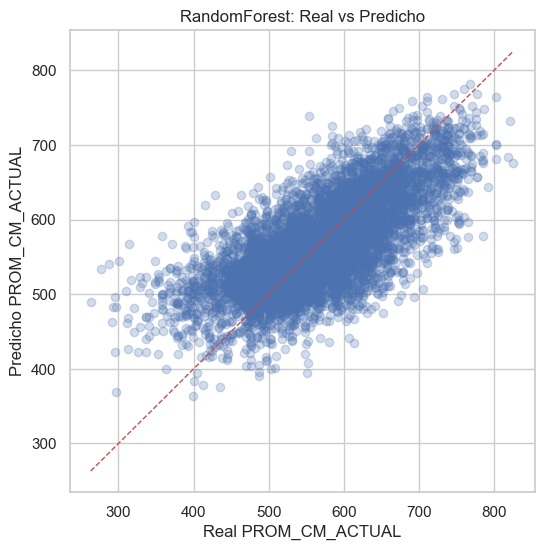

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_rf, alpha=0.25)
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Real PROM_CM_ACTUAL')
plt.ylabel('Predicho PROM_CM_ACTUAL')
plt.title('RandomForest: Real vs Predicho')
plt.show()


## 2) Clasificacion: alto desempeno academico

Definicion: `PROM_CM_ACTUAL` por sobre el percentil 75.

In [15]:
q75 = work[target_reg].quantile(0.75)
work_cls = work.copy()
work_cls['alto_desempeno'] = (work_cls[target_reg] >= q75).astype(int)

Xc = work_cls[feature_cols]
yc = work_cls['alto_desempeno']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc
)

baseline_cls = Pipeline([
    ('preprocess', preprocess),
    ('model', DummyClassifier(strategy='prior')),
])

rf_cls = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    )),
])

baseline_cls.fit(Xc_train, yc_train)
rf_cls.fit(Xc_train, yc_train)

proba_base = baseline_cls.predict_proba(Xc_test)[:, 1]
proba_rf = rf_cls.predict_proba(Xc_test)[:, 1]
pred_rf_cls = (proba_rf >= 0.5).astype(int)

res_cls = pd.DataFrame([
    {
        'modelo': 'DummyClassifier(prior)',
        'AUC': roc_auc_score(yc_test, proba_base),
        'F1@0.5': f1_score(yc_test, (proba_base >= 0.5).astype(int))
    },
    {
        'modelo': 'RandomForestClassifier',
        'AUC': roc_auc_score(yc_test, proba_rf),
        'F1@0.5': f1_score(yc_test, pred_rf_cls)
    }
]).sort_values('AUC', ascending=False)

display(res_cls)
print('\nReporte RandomForestClassifier:')
print(classification_report(yc_test, pred_rf_cls, digits=3))


,modelo,AUC,F1@0.5
1,RandomForestClassifier,0.852111,0.623352
0,DummyClassifier(prior),0.500000,0.000000



Reporte RandomForestClassifier:
              precision    recall  f1-score   support

           0      0.861     0.919     0.889      5232
           1      0.701     0.561     0.623      1769

    accuracy                          0.829      7001
   macro avg      0.781     0.740     0.756      7001
weighted avg      0.821     0.829     0.822      7001



## 3) Clustering de perfiles

Se usa KMeans con variables numericas principales y seleccion de `k` via silhouette.

In [16]:
cluster_vars = [c for c in ['PTJE_NEM', 'PTJE_RANKING', 'PROM_CM_ACTUAL', 'IVM_Establecimiento', 'DISTANCIA'] if c in work.columns]
if len(cluster_vars) < 3:
    raise ValueError('Se necesitan al menos 3 variables numericas para clustering util.')

clu = work[cluster_vars].copy().dropna()
scaler = StandardScaler()
Xclu = scaler.fit_transform(clu)

scores = []
k_values = list(range(2, 9))
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(Xclu)
    s = silhouette_score(Xclu, labels)
    scores.append((k, s))

sil_df = pd.DataFrame(scores, columns=['k', 'silhouette'])
best_k = int(sil_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
print('Mejor k por silhouette:', best_k)
display(sil_df)

km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clu['cluster'] = km_best.fit_predict(Xclu)

display(clu.groupby('cluster')[cluster_vars].mean().round(2))


Mejor k por silhouette: 3


,k,silhouette
0,2,0.309785
1,3,0.330159
2,4,0.276027
3,5,0.263677
4,6,0.247756
5,7,0.250066
6,8,0.244566


,PTJE_NEM,PTJE_RANKING,PROM_CM_ACTUAL,IVM_Establecimiento,DISTANCIA
cluster,,,,,
0,720.55,761.70,608.24,16.24,54.05
1,667.69,693.76,583.75,15.58,1202.95
2,563.51,576.36,515.30,16.27,48.08


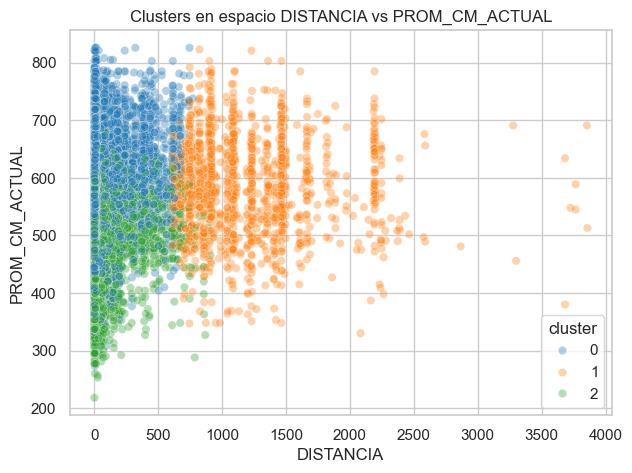

In [17]:
if {'PROM_CM_ACTUAL', 'DISTANCIA'}.issubset(clu.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=clu, x='DISTANCIA', y='PROM_CM_ACTUAL', hue='cluster', alpha=0.35, palette='tab10')
    plt.title('Clusters en espacio DISTANCIA vs PROM_CM_ACTUAL')
    plt.show()


## 4) Importancia de variables (Permutation Importance)

Aporta interpretabilidad para priorizar variables en politica publica.

In [18]:
# Regresion
pi_reg = permutation_importance(
    rf_reg,
    X_test,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pi_reg_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': pi_reg.importances_mean,
    'importance_std': pi_reg.importances_std,
}).sort_values('importance_mean', ascending=False)

display(pi_reg_df.head(12))


,feature,importance_mean,importance_std
0,PTJE_NEM,2.155280e+01,3.108216e-01
4,TIPO_DEPEN,6.231316e+00,2.030712e-01
2,IVM_Establecimiento,4.506662e+00,2.257191e-01
10,tipo_inst_2,4.155744e+00,2.756383e-01
1,PTJE_RANKING,1.324228e+00,1.688247e-01
8,comuna_sede,1.118649e+00,7.764930e-02
5,NOMBRE_REGION_EGRESO,8.211765e-01,7.824676e-02
3,DISTANCIA,7.359148e-01,7.469186e-02
6,NOMBRE_REGION_INGRESO,4.807983e-01,8.889869e-02
7,region_sede,4.330384e-01,1.035860e-01


In [19]:
# Clasificacion
pi_cls = permutation_importance(
    rf_cls,
    Xc_test,
    yc_test,
    scoring='roc_auc',
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pi_cls_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': pi_cls.importances_mean,
    'importance_std': pi_cls.importances_std,
}).sort_values('importance_mean', ascending=False)

display(pi_cls_df.head(12))


,feature,importance_mean,importance_std
0,PTJE_NEM,0.087934,0.003306
10,tipo_inst_2,0.022359,0.002452
4,TIPO_DEPEN,0.009144,0.001689
2,IVM_Establecimiento,0.008981,0.001917
1,PTJE_RANKING,0.004591,0.001544
8,comuna_sede,0.000912,0.001892
3,DISTANCIA,0.000167,0.000804
9,tipo_inst_1,0.000000,0.000000
11,nivel_global,0.000000,0.000000
12,rango_edad,0.000000,0.000000


## Siguientes mejoras sugeridas

- Validacion temporal (train con anios previos, test en anio futuro).
- Evaluacion por subgrupos (`TIPO_DEPEN`, region, sexo si disponible).
- Calibracion de probabilidades en clasificacion (`CalibratedClassifierCV`).
- Modelos gradiente boosting (XGBoost/LightGBM) para comparar desempeno.
